# Introduzione all'analisi dei dati

Viviamo in un mondo in cui una grande quantità di informazioni viene raccolta continuamente: immagini mediche, misure ambientali, transazioni economiche, dati provenienti dai social network, segnali acquisiti da sensori e risultati di esperimenti scientifici.

Queste informazioni vengono rappresentate sotto forma di **dati**. Tuttavia, possedere molti dati non significa automaticamente possedere conoscenza. I dati possono essere incompleti, rumorosi, ridondanti o difficili da interpretare.

L'obiettivo dell'**analisi dei dati** è estrarre dai dati informazioni significative, individuare regolarità e costruire modelli utili per descrivere o prevedere un fenomeno.

Possiamo riassumere il processo nel seguente schema:

$$
\text{dati grezzi}
\longrightarrow
\text{rappresentazione matematica}
\longrightarrow
\text{metodo numerico}
\longrightarrow
\text{informazione}.
$$

### Obiettivi della lezione

Al termine di questa introduzione dovremmo essere in grado di:

- spiegare che cosa si intende per analisi dei dati;
- distinguere osservazioni, variabili e caratteristiche;
- rappresentare un insieme di dati mediante vettori e matrici;
- riconoscere diversi tipi di analisi;
- effettuare una prima esplorazione numerica e grafica dei dati;
- comprendere il ruolo del rumore, dell'errore e dei metodi numerici.

## 1. Che cos'è l'analisi dei dati?

L'analisi dei dati comprende l'insieme delle tecniche utilizzate per:

1. raccogliere e organizzare i dati;
2. controllarne qualità e coerenza;
3. rappresentarli in una forma matematica;
4. esplorarli mediante statistiche e visualizzazioni;
5. individuare relazioni e strutture;
6. costruire e valutare modelli;
7. formulare previsioni o prendere decisioni.

L'analisi dei dati non è quindi una singola tecnica, ma un **processo** nel quale matematica, statistica e informatica interagiscono.

### 1.1 L'analisi dei dati è interdisciplinare

L'analisi dei dati si trova all'intersezione di tre aree:

- **informatica**, necessaria per rappresentare, elaborare e gestire i dati;
- **matematica e statistica**, che forniscono modelli e strumenti per interpretarli;
- **conoscenza del dominio applicativo**, indispensabile per formulare domande sensate e valutare i risultati.

```{figure} immagini_sorgente/an_dati1.png
---
width: 60%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente\an_dati1.png"  width="400">
</p> -->


## 1.2 Il ciclo di vita dell'analisi dei dati

Un progetto di analisi dei dati non coincide con la sola costruzione di un modello. È un processo iterativo: si formula il problema, si raccolgono e preparano i dati, si esplorano le informazioni disponibili, si costruisce il modello e se ne valuta l'efficacia.

```{figure} immagini_sorgente/an_dati2.png
---
width: 60%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente\an_dati2.png"  width="400">
</p> -->


I risultati ottenuti possono suggerire di modificare il modello, raccogliere nuovi dati o persino riformulare la domanda iniziale.



*Analisi descrittiva*

Risponde alla domanda: **che cosa mostrano i dati?**

Comprende, per esempio, il calcolo di media, mediana, varianza e quantili, oltre alla costruzione di tabelle e grafici.

*Analisi esplorativa*

Cerca strutture non note in anticipo, come gruppi di osservazioni simili, variabili associate, dati anomali e direzioni principali di variabilità.

*Analisi predittiva*

Utilizza i dati disponibili per prevedere quantità non ancora osservate. Alcuni esempi sono prevedere il prezzo di un'abitazione, classificare un messaggio come spam o riconoscere un oggetto in un'immagine.## Dati, informazione e conoscenza

È utile distinguere tre concetti:

- i **dati** sono le osservazioni raccolte;
- l'**informazione** nasce dall'organizzazione e dall'interpretazione dei dati;
- la **conoscenza** permette di utilizzare l'informazione per comprendere un fenomeno o prendere decisioni.

Un algoritmo può individuare una struttura nei dati, ma il risultato deve essere interpretato nel contesto del problema. Un'associazione tra due variabili, per esempio, non implica necessariamente una relazione di causa ed effetto.
### 1.3 La qualità dei dati

Prima di applicare qualsiasi metodo è necessario esaminare la qualità dei dati. I problemi più comuni sono:

- **valori mancanti**, dovuti a misure non effettuate o informazioni non disponibili;
- **valori anomali** (*outlier*), molto lontani dalla maggior parte delle osservazioni;
- **errori di acquisizione o trascrizione**;
- **unità di misura differenti**;
- **duplicati**;
- **campioni non rappresentativi** della popolazione che vogliamo studiare.

La pulizia dei dati non è un passaggio secondario: risultati numericamente corretti possono essere privi di significato se i dati di partenza sono inaffidabili.


*Il ruolo dell'errore e del rumore*

L'errore è inevitabile nell'analisi dei dati. Può derivare da errori di misura, dati mancanti, rumore, approssimazioni del modello, errori di arrotondamento o interruzione anticipata di un algoritmo iterativo.

Possiamo rappresentare una misura mediante

$$
y^\delta = y + \eta,
$$

dove $y$ è il valore ideale, $\eta$ rappresenta il rumore e $y^\delta$ è il dato effettivamente osservato.

Un algoritmo affidabile deve estrarre l'informazione utile senza interpretare il rumore come una caratteristica significativa del fenomeno.

*Segnale ideale e misure rumorose*

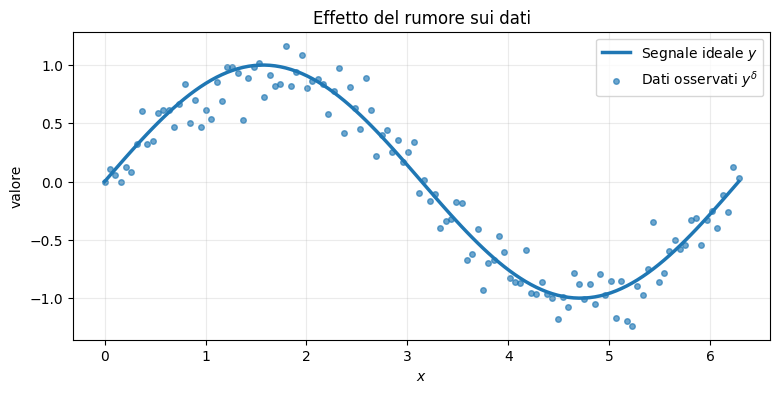

In [9]:
import numpy as np
import matplotlib.pyplot as plt 

rng = np.random.default_rng(7)
x = np.linspace(0, 2 * np.pi, 120)
y = np.sin(x)
eta = 0.18 * rng.standard_normal(x.size)
y_delta = y + eta

plt.figure(figsize=(9, 4))
plt.plot(x, y, linewidth=2.5, label='Segnale ideale $y$')
plt.scatter(x, y_delta, s=16, alpha=0.65, label=r'Dati osservati $y^\delta$')
plt.xlabel('$x$')
plt.ylabel('valore')
plt.title('Effetto del rumore sui dati')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### 1.4 Perché servono i metodi numerici?

Nei problemi reali raramente è possibile ottenere una soluzione esatta mediante una formula. I dati possono essere numerosi, rumorosi o mal condizionati, e il modello può essere troppo complesso per essere trattato analiticamente.

I metodi numerici consentono di calcolare una soluzione approssimata utilizzando un calcolatore. È però necessario porsi alcune domande fondamentali:

- L'algoritmo produce una soluzione sufficientemente accurata?
- Quanto è grande l'errore?
- La soluzione cambia molto se i dati sono perturbati?
- Quanto tempo e quanta memoria sono necessari?
- L'algoritmo converge?
- Il risultato descrive davvero il fenomeno oppure riproduce anche il rumore?

Un metodo numerico non deve quindi essere soltanto implementabile: deve anche essere **accurato, stabile ed efficiente**.

**La pipeline dell'analisi dei dati**

Nel corso utilizzeremo ripetutamente la seguente sequenza concettuale:

$$
\boxed{
\text{problema}
\rightarrow
\text{dati}
\rightarrow
\text{modello}
\rightarrow
\text{algoritmo}
\rightarrow
\text{valutazione}
}
$$

Il messaggio centrale è:

> L'analisi dei dati non consiste semplicemente nell'applicare un algoritmo. Consiste nel formulare correttamente una domanda, rappresentare i dati, scegliere un modello, calcolare una soluzione e valutarne criticamente l'affidabilità.


### 2.6 La scelta del modello

Gli stessi dati possono essere rappresentati utilizzando *modelli* differenti. Per esempio, possiamo scegliere come modello una retta oppure una parabola.

```{figure} immagini_sorgente/modelli_lineare_quadratico.png
---
width: 100%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente/modelli_lineare_quadratico.png" width="700">
</p> -->

Nel primo caso il modello ha la forma

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x,
$$

mentre nel secondo caso ha la forma

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x+\theta_2x^2.
$$

### 2.6 La scelta del modello

Gli stessi dati possono essere rappresentati utilizzando *modelli* differenti. Per esempio, possiamo scegliere come modello una retta oppure una parabola.

```{figure} immagini_sorgente/modelli_lineare_quadratico.png
---
width: 100%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente/modelli_lineare_quadratico.png" width="700">
</p> -->

Nel primo caso il modello ha la forma

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x,
$$

mentre nel secondo caso ha la forma

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x+\theta_2x^2.
$$

La famiglia scelta non deve necessariamente essere quella dei polinomi. Per esempio, possiamo considerare una combinazione lineare di una funzione esponenziale e di una costante:

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1 e^{\alpha x}.
$$

```{figure} immagini_sorgente/modello_esponenziale.png
---
width: 100%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente/modello_esponenziale.png" width="700">
</p> -->

La scelta della famiglia di funzioni dipende dal fenomeno che vogliamo descrivere e dalle informazioni disponibili sui dati.

### 2.6 I modelli: famiglie parametriche di funzioni

Scelta una famiglia di funzioni $f(x;\boldsymbol{\theta})$, occorre determinare i parametri

$$
\boldsymbol{\theta}=(\theta_0,\theta_1,\ldots,\theta_{k-1})^T\in\mathbb{R}^{k}
$$

che identificano la particolare funzione della famiglia che meglio rappresenta i dati.

Per esempio, scegliendo come famiglia le rette del piano, dobbiamo determinare

$$
\boldsymbol{\theta}=(\theta_0,\theta_1)^T,
$$

dove $\theta_0$ è l'intercetta e $\theta_1$ è il coefficiente angolare. Il problema consiste quindi nel trovare la retta che meglio approssima i punti dati.

**Come confrontare due modelli?**

Per stabilire se una funzione rappresenta i dati meglio di un'altra dobbiamo introdurre una misura di vicinanza tra i valori previsti e quelli osservati.

Questo viene fatto definendo una **funzione di costo**, detta anche **funzione di perdita** o *loss function*. Indicata con $h$ la perdita relativa a una singola osservazione, definiamo

$$
\mathcal{L}(\boldsymbol{\theta})
=\sum_{i=1}^{n}h\bigl(f(x_i;\boldsymbol{\theta}),y_i\bigr).
$$

La funzione di costo dipende dai parametri perché, al variare di $\boldsymbol{\theta}$, cambiano le previsioni del modello.

*Il calcolo dei parametri come problema di minimo*

I parametri ottimali sono quelli che rendono minima la funzione di costo:

$$
\boldsymbol{\theta}^{*}
=\operatorname*{argmin}_{\boldsymbol{\theta}\in\mathbb{R}^{k}}
\mathcal{L}(\boldsymbol{\theta}).
$$

La funzione $f(x;\boldsymbol{\theta}^{*})$, i cui parametri sono stati stimati minimizzando la funzione di perdita, prende il nome di **funzione di regressione**.

> Il problema di costruire un modello predittivo viene così trasformato in un problema di ottimizzazione.

### 2.7 L'approccio del Machine Learning

Nella programmazione tradizionale il programmatore specifica esplicitamente le regole che trasformano i dati in risultati. Questo approccio diventa difficile quando le regole sono troppo numerose, complesse o impossibili da descrivere in modo preciso.

Nel **Machine Learning** non scriviamo direttamente tutte le regole: forniamo esempi a un algoritmo, che cerca nei dati le regolarità utili per costruire un modello predittivo.

![](immagini_sorgente/tradizionale_vs_ml.png)

<!-- ```{figure} immagini_sorgente/tradizionale_vs_ml.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/tradizionale_vs_ml.png" width="700">
</p> -->

> Un sistema di Machine Learning apprende dai dati una regola che non è stata programmata esplicitamente.

*Imparare dagli esempi*

L'apprendimento automatico può essere paragonato allo studio di uno studente:

- durante il **training**, lo studente studia esempi ed esercizi già svolti;
- durante il **test**, affronta domande nuove;
- la **valutazione** misura quanto ciò che ha appreso sia trasferibile a situazioni mai viste.

![](studying_training_evaluation.png)

<!-- ```{figure} immagini_sorgente/studying_training_evaluation.png
---
width: 100%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente/studying_training_evaluation.png" width="700">
</p> --> -->

Se le domande dell'esame fossero identiche agli esercizi studiati, non potremmo capire se lo studente ha davvero imparato. Analogamente, un modello deve essere valutato su dati non utilizzati durante il training.



Nell'**apprendimento supervisionato** disponiamo di un insieme di esempi

$$
\mathcal{D}_{\mathrm{train}}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{m},
$$

dove $\mathbf{x}_i$ contiene le caratteristiche dell'osservazione e $y_i$ è la risposta corretta.

L'**algoritmo di apprendimento** usa il training set per determinare un modello $f_{\boldsymbol{\theta}}$. Una volta costruito, il modello riceve un nuovo input e produce una previsione:

$$
\mathbf{x}_{\mathrm{new}}
\longrightarrow
f_{\boldsymbol{\theta}}(\mathbf{x}_{\mathrm{new}})
=\widehat{y}_{\mathrm{new}}.
$$

È importante distinguere:

- l'**algoritmo**, cioè la procedura che apprende;
- il **modello**, cioè la funzione ottenuta al termine dell'apprendimento;
- la **predizione**, cioè l'output del modello per un nuovo dato.

### 2.8 L'obiettivo: generalizzare

Lo scopo non è riprodurre perfettamente gli esempi già osservati, ma ottenere buone previsioni su dati nuovi. Questa capacità prende il nome di **generalizzazione**.

![](immagini_sorgente/training_test.png)

<!-- ```{figure} immagini_sorgente/training_test.png
---
width: 100%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente/training_test.png" width="700">
</p> --> -->

- Il **training set** serve ad apprendere i parametri del modello.
- Il **test set** deve essere usato soltanto per la valutazione finale.

Un modello troppo semplice può non cogliere la struttura dei dati (**underfitting**); un modello che si adatta anche al rumore del training set può invece non funzionare su nuovi dati (**overfitting**).

> La qualità di un modello si misura sulla sua capacità di prevedere, non sulla sua capacità di ricordare.